In [ ]:
import pandas as pd
import matplotlib.pyplot as plt  # for graph plotting
from sklearn.preprocessing import LabelEncoder #for data preprocessing(text to numerical replacement)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/cancer patient data sets.csv")
print(df.head())

   index Patient Id  Age  Gender  Air Pollution  Alcohol use  Dust Allergy  \
0      0         P1   33       1              2            4             5   
1      1        P10   17       1              3            1             5   
2      2       P100   35       1              4            5             6   
3      3      P1000   37       1              7            7             7   
4      4       P101   46       1              6            8             7   

   OccuPational Hazards  Genetic Risk  chronic Lung Disease  ...  Fatigue  \
0                     4             3                     2  ...        3   
1                     3             4                     2  ...        1   
2                     5             5                     4  ...        8   
3                     7             6                     7  ...        4   
4                     7             7                     6  ...        3   

   Weight Loss  Shortness of Breath  Wheezing  Swallowing Difficulty

In [ ]:
age_col = df['Age']
gender_col = df['Gender']

print("AGE column: ")
print(age_col.head())

print("\nGENDER column:")
print(gender_col.head())

AGE column: 
0    33
1    17
2    35
3    37
4    46
Name: Age, dtype: int64

GENDER column:
0    1
1    1
2    1
3    1
4    1
Name: Gender, dtype: int64


In [ ]:
print(df.columns)

Index(['index', 'Patient Id', 'Age', 'Gender', 'Air Pollution', 'Alcohol use',
       'Dust Allergy', 'OccuPational Hazards', 'Genetic Risk',
       'chronic Lung Disease', 'Balanced Diet', 'Obesity', 'Smoking',
       'Passive Smoker', 'Chest Pain', 'Coughing of Blood', 'Fatigue',
       'Weight Loss', 'Shortness of Breath', 'Wheezing',
       'Swallowing Difficulty', 'Clubbing of Finger Nails', 'Frequent Cold',
       'Dry Cough', 'Snoring', 'Level'],
      dtype='object')


In [ ]:
chronic_disease_col = df['chronic Lung Disease']
print("CHRONIC DISEASE column:")
print(chronic_disease_col.head())

CHRONIC DISEASE column:
0    2
1    2
2    4
3    7
4    6
Name: chronic Lung Disease, dtype: int64


In [ ]:
# row selection
first_row = df.iloc[0]
rows_0_4 = df.iloc[0:5]

print("\nFirst row:")
print(first_row)

print("\nRows 0-4:")
print(rows_0_4)

age_val = df[df['Age'] > 68]
print("\nAGE > 68:")
print(age_val)


First row:
index                         0
Patient Id                   P1
Age                          33
Gender                        1
Air Pollution                 2
Alcohol use                   4
Dust Allergy                  5
OccuPational Hazards          4
Genetic Risk                  3
chronic Lung Disease          2
Balanced Diet                 2
Obesity                       4
Smoking                       3
Passive Smoker                2
Chest Pain                    2
Coughing of Blood             4
Fatigue                       3
Weight Loss                   4
Shortness of Breath           2
Wheezing                      2
Swallowing Difficulty         3
Clubbing of Finger Nails      1
Frequent Cold                 2
Dry Cough                     3
Snoring                       4
Level                       Low
Name: 0, dtype: object

Rows 0-4:
   index Patient Id  Age  Gender  Air Pollution  Alcohol use  Dust Allergy  \
0      0         P1   33       1            

In [ ]:
print(df.isnull().sum())

index                       0
Patient Id                  0
Age                         0
Gender                      0
Air Pollution               0
Alcohol use                 0
Dust Allergy                0
OccuPational Hazards        0
Genetic Risk                0
chronic Lung Disease        0
Balanced Diet               0
Obesity                     0
Smoking                     0
Passive Smoker              0
Chest Pain                  0
Coughing of Blood           0
Fatigue                     0
Weight Loss                 0
Shortness of Breath         0
Wheezing                    0
Swallowing Difficulty       0
Clubbing of Finger Nails    0
Frequent Cold               0
Dry Cough                   0
Snoring                     0
Level                       0
dtype: int64


In [ ]:
print(df['Age'].mean())
print(df['Age'].max())
print(df['Age'].min())
print(df['Age'].value_counts())

37.174
73
14
Age
35    77
33    69
38    69
37    51
44    51
27    48
45    42
48    40
26    37
28    32
52    31
32    31
25    30
24    30
62    30
46    23
39    21
36    21
17    20
47    20
42    20
19    20
29    19
53    19
23    19
22    19
18    18
55    11
34    10
65    10
73    10
64    10
49    10
61    10
14     9
31     9
43     1
51     1
54     1
63     1
Name: count, dtype: int64


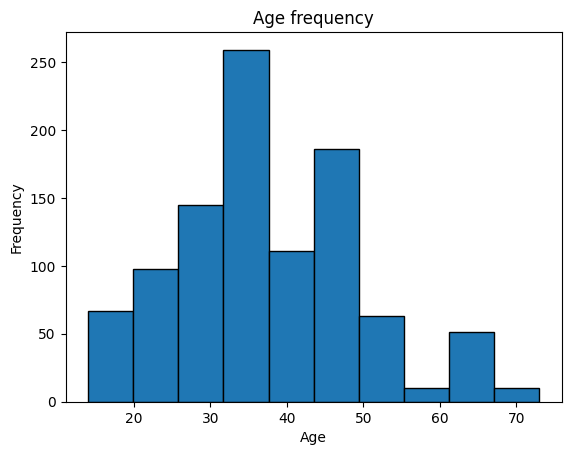

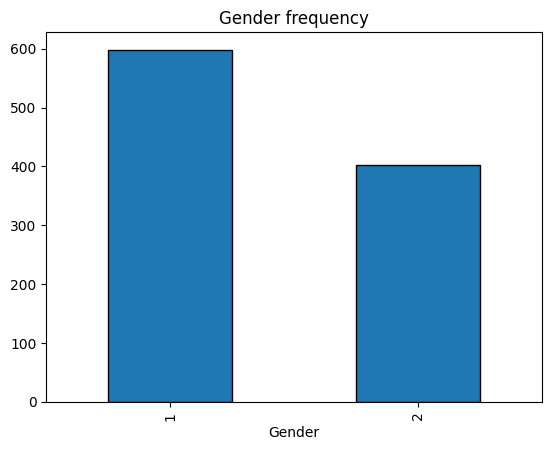

In [ ]:
df['Age'].hist(bins=10, grid=False, edgecolor='black')
plt.title('Age frequency')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

# bar plot
df['Gender'].value_counts().plot(kind='bar', edgecolor='black')
plt.title('Gender frequency')
plt.show()

In [ ]:
le = LabelEncoder()
df['Level'] = le.fit_transform(df['Level'])
print(df['Level'])
print(df.head())

0      1
1      2
2      0
3      0
4      0
      ..
995    0
996    0
997    0
998    0
999    0
Name: Level, Length: 1000, dtype: int64
   index Patient Id  Age  Gender  Air Pollution  Alcohol use  Dust Allergy  \
0      0         P1   33       1              2            4             5   
1      1        P10   17       1              3            1             5   
2      2       P100   35       1              4            5             6   
3      3      P1000   37       1              7            7             7   
4      4       P101   46       1              6            8             7   

   OccuPational Hazards  Genetic Risk  chronic Lung Disease  ...  Fatigue  \
0                     4             3                     2  ...        3   
1                     3             4                     2  ...        1   
2                     5             5                     4  ...        8   
3                     7             6                     7  ...        4   
4      

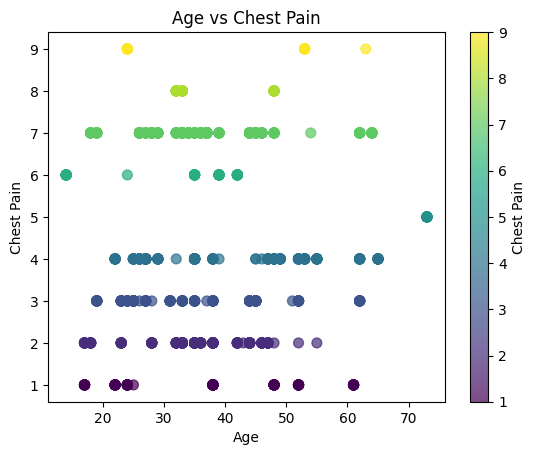

In [ ]:
plt.scatter(df['Age'], df['Chest Pain'], c=df['Chest Pain'], cmap='viridis', s=50, alpha=0.7)
plt.xlabel('Age')
plt.ylabel('Chest Pain')
plt.title('Age vs Chest Pain')
plt.colorbar(label='Chest Pain')
plt.show()

In [ ]:
# # model training and validation libraries

# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import accuracy_score, confusion_matrix

In [ ]:
# all cols except the target variable 'Level'
x = df.drop('Level', axis=1)
# target variable
y = df['Level']

# Encode the 'Gender' column to numerical values
x['Gender'] = le.fit_transform(x['Gender'])

# split dataset into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.8, random_state=42)

print('Training Sample',x_train.shape[0])
print('Testing Sample',x_test.shape[0])

Training Sample 200
Testing Sample 800


In [ ]:
#Features Scaling

from sklearn.preprocessing import StandardScaler

# Drop non-numeric identifier columns before scaling
x_train_processed = x_train.drop(columns=['index', 'Patient Id'], errors='ignore')
x_test_processed = x_test.drop(columns=['index', 'Patient Id'], errors='ignore')

scalar = StandardScaler()
x_train_scaled = scalar.fit_transform(x_train_processed)
x_test_scaled = scalar.transform(x_test_processed)

# Print the first 5 rows of the scaled training data
print("scaled x_train (first 5 rows):\n", x_train_scaled[:5])

scaled x_train (first 5 rows):
 [[ 2.27418227 -0.74188112  1.0262379   1.33978769  0.96323298  1.03499365
   1.16613833  0.83306809  1.1468678   1.13437306  1.11228276  1.57519928
   1.04913483  0.81449073  2.21815977  1.1588785   0.33555208  1.66616125
  -0.77803361  0.0158865  -0.35684805 -1.39908314  0.62675217]
 [-0.42965695 -0.74188112 -1.43476426  0.55167728  0.96323298  0.11295031
  -0.75738881 -1.2826604   0.67684002 -1.1526694  -0.50264684 -0.52506643
  -1.16422979 -1.24230405 -0.3940009  -0.24299065  1.20149292  1.66616125
   0.16503743  1.83148649  1.78960636  1.46105275  1.28649129]
 [ 2.10519232 -0.74188112  1.0262379   1.33978769  0.96323298  1.03499365
   1.16613833  0.83306809  1.1468678   1.13437306  1.51601515  1.15514614
   1.04913483  1.63720864 -0.3940009  -0.71028037 -0.09741834 -1.23151049
   0.16503743 -0.89191349  0.17976556 -0.92239383 -0.03298696]
 [-0.09167705 -0.74188112  1.0262379   0.94573249  0.96323298  1.03499365
   1.16613833  1.36200022  0.67684002  

In [ ]:
#Train a logistic regression model
model = LogisticRegression()
model.fit(x_train_scaled, y_train)

# Make predictions
y_pred = model.predict(x_test_scaled)

# evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print("Accuracy:", accuracy)
print("Confusion Matrix:\n", conf_matrix)

Accuracy: 1.0
Confusion Matrix:
 [[284   0   0]
 [  0 242   0]
 [  0   0 274]]


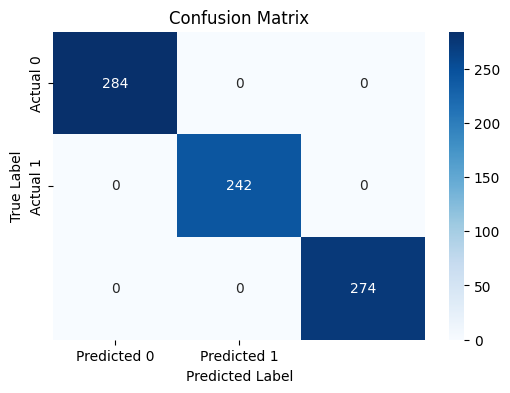

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot configuration matrix
plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix,annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])

plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()